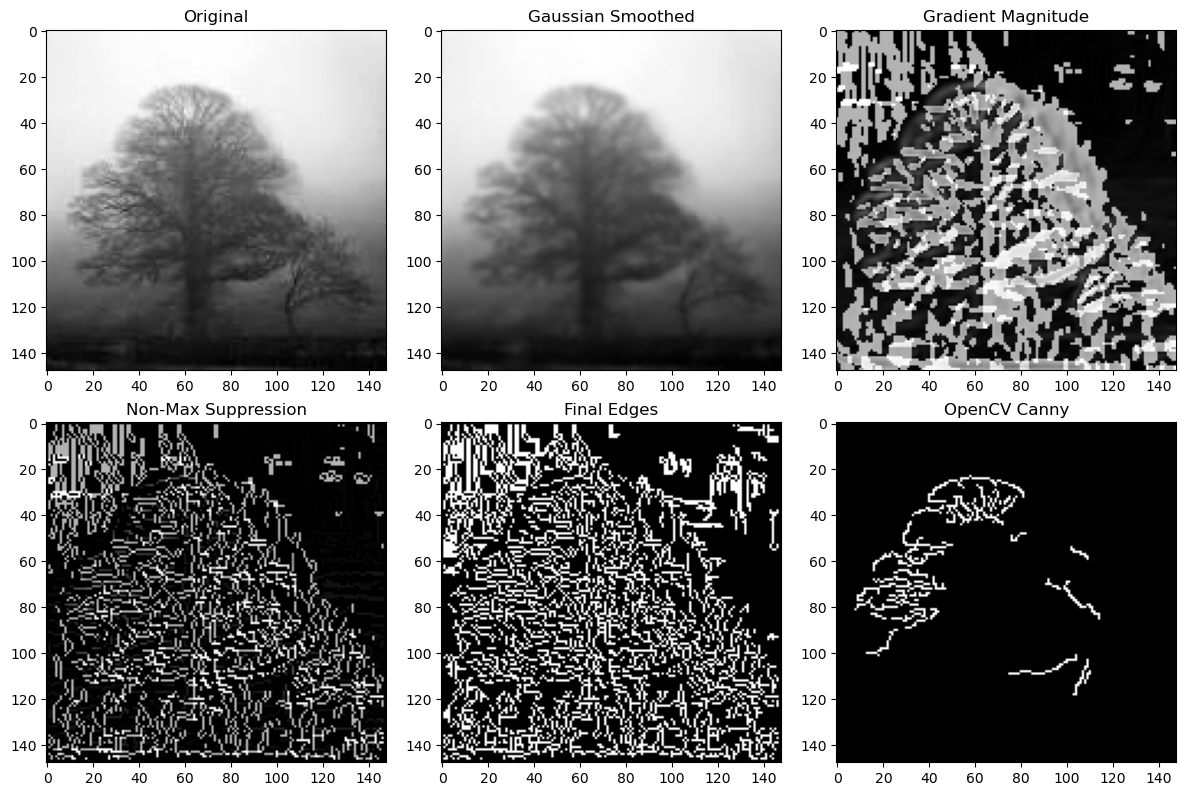

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# -------------------------------
# Step 1: Gaussian Smoothing
# -------------------------------
def gaussian_kernel(size, sigma=1):
    """Generate a Gaussian kernel."""
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    g = np.exp(-(x**2 + y**2)/(2*sigma**2))
    return g / g.sum()

def gaussian_smoothing(img, kernel_size=5, sigma=1):
    kernel = gaussian_kernel(kernel_size, sigma)
    return convolve(img, kernel)

# -------------------------------
# Step 2: Gradient Computation
# -------------------------------
def compute_gradients(img):
    # Sobel kernels
    Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    Ky = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
    
    Ix = convolve(img, Kx)
    Iy = convolve(img, Ky)
    
    # Gradient magnitude and direction
    G = np.hypot(Ix, Iy)
    G = G / G.max() * 255
    theta = np.arctan2(Iy, Ix)
    return G, theta

# -------------------------------
# Step 3: Non-Maximum Suppression
# -------------------------------
def non_maximum_suppression(G, theta):
    M, N = G.shape
    Z = np.zeros((M,N), dtype=np.float32)
    angle = theta * 180. / np.pi
    angle[angle < 0] += 180
    
    for i in range(1,M-1):
        for j in range(1,N-1):
            q = 255
            r = 255
            
            # Angle 0
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = G[i, j+1]
                r = G[i, j-1]
            # Angle 45
            elif (22.5 <= angle[i,j] < 67.5):
                q = G[i+1, j-1]
                r = G[i-1, j+1]
            # Angle 90
            elif (67.5 <= angle[i,j] < 112.5):
                q = G[i+1, j]
                r = G[i-1, j]
            # Angle 135
            elif (112.5 <= angle[i,j] < 157.5):
                q = G[i-1, j-1]
                r = G[i+1, j+1]
            
            if (G[i,j] >= q) and (G[i,j] >= r):
                Z[i,j] = G[i,j]
            else:
                Z[i,j] = 0
    return Z

# -------------------------------
# Step 4: Hysteresis Thresholding
# -------------------------------
def hysteresis(img, low_ratio=0.05, high_ratio=0.15):
    high = img.max() * high_ratio
    low = high * low_ratio
    
    M, N = img.shape
    res = np.zeros((M,N), dtype=np.int32)
    
    strong = np.int32(255)
    weak = np.int32(75)
    
    strong_i, strong_j = np.where(img >= high)
    zeros_i, zeros_j = np.where(img < low)
    
    weak_i, weak_j = np.where((img <= high) & (img >= low))
    
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    
    # Track edges
    for i in range(1, M-1):
        for j in range(1, N-1):
            if res[i,j] == weak:
                if ((res[i+1, j-1] == strong) or (res[i+1, j] == strong) or (res[i+1, j+1] == strong)
                    or (res[i, j-1] == strong) or (res[i, j+1] == strong)
                    or (res[i-1, j-1] == strong) or (res[i-1, j] == strong) or (res[i-1, j+1] == strong)):
                    res[i,j] = strong
                else:
                    res[i,j] = 0
    return res

# -------------------------------
# Full Canny Pipeline
# -------------------------------
def canny_edge_detector(img, kernel_size=5, sigma=1, low_ratio=0.05, high_ratio=0.15):
    smoothed = gaussian_smoothing(img, kernel_size, sigma)
    grad, theta = compute_gradients(smoothed)
    nms = non_maximum_suppression(grad, theta)
    edges = hysteresis(nms, low_ratio, high_ratio)
    return smoothed, grad, nms, edges

# -------------------------------
# Testing & Visualization
# -------------------------------
img = cv2.imread("image1.jpeg", 0)  # Read grayscale image

smoothed, grad, nms, edges = canny_edge_detector(img)

# Plot intermediate results
plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.subplot(2,3,2); plt.imshow(smoothed, cmap='gray'); plt.title("Gaussian Smoothed")
plt.subplot(2,3,3); plt.imshow(grad, cmap='gray'); plt.title("Gradient Magnitude")
plt.subplot(2,3,4); plt.imshow(nms, cmap='gray'); plt.title("Non-Max Suppression")
plt.subplot(2,3,5); plt.imshow(edges, cmap='gray'); plt.title("Final Edges")
plt.subplot(2,3,6); plt.imshow(cv2.Canny(img, 100, 200), cmap='gray'); plt.title("OpenCV Canny")
plt.tight_layout()
plt.show()
